### Fase 1 - Exploración

In [61]:
# Importar librerías 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
# Importar archivo csv - se usa encoding="latin1" porque el archivo original se genero bajo el estándar de 1 solo byte por carácter
df = pd.read_csv('Appendix 1 - Database.csv', encoding="latin1")

In [63]:
# Información filas y columnas del DataFrame
print("\nCantidad de filas y columnas del DataFrame", df.shape)


Cantidad de filas y columnas del DataFrame (541909, 8)


In [64]:
# Estructura del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [65]:
# Limpieza de encabezados, eliminar espacios en los extremos, convertimos a minúsculas y espacios internos por '_'
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

# Conversiones de tipos de datos
df['customerid'] = pd.to_numeric(df['customerid'], errors='coerce')
df['invoicedate'] = pd.to_datetime(df['invoicedate'])

# Filtrar registros no deseados (boolean masks)
# Se usa .copy() para evitar el SettingWithCopyWarning
df = df[(df['quantity'] > 0) & (df['unitprice'] > 0)].copy()

# Eliminar valores faltantes en la columna customerid 
df = df.dropna(subset=['customerid'])

# Eliminar registros duplicados
df = df.drop_duplicates().copy()

# Al eliminar muchas filas, los índices tienen "huecos" con reset_index() los reorganiza de 0 a N.
df = df.reset_index(drop=True)

# Con los datos limpios, creamos totalprice = quantity * unitprice (operaciones vectorizadas)
df['totalprice'] = df['quantity'] * df['unitprice']

print(f"Dimensiones del DataFrame: {df.shape}\n")
df.info()

Dimensiones del DataFrame: (392692, 9)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   invoiceno    392692 non-null  object        
 1   stockcode    392692 non-null  object        
 2   description  392692 non-null  object        
 3   quantity     392692 non-null  int64         
 4   invoicedate  392692 non-null  datetime64[ns]
 5   unitprice    392692 non-null  float64       
 6   customerid   392692 non-null  float64       
 7   country      392692 non-null  object        
 8   totalprice   392692 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 27.0+ MB


In [66]:
# Calcular totales por factura
totalesfacturas = df.groupby("invoiceno")["totalprice"].sum().reset_index()

print("Totales por Factura:")
print(totalesfacturas)

Totales por Factura:
      invoiceno  totalprice
0        536365      139.12
1        536366       22.20
2        536367      278.73
3        536368       70.05
4        536369       17.85
...         ...         ...
18527    581583      124.60
18528    581584      140.64
18529    581585      329.05
18530    581586      339.20
18531    581587      249.45

[18532 rows x 2 columns]


In [73]:
# Agrupamos por ID del cliente para calcular la suma de totalprice (Gasto total) y cantidad de facturas únicas (indica nivel de lealtad)
metricas_cliente = df.groupby("customerid").agg({
    "totalprice": "sum",
    "invoiceno": "nunique"  # 'nunique' cuenta valores únicos (facturas)
}).reset_index()

# Renombramos las columnas 
metricas_cliente.columns = ['customerid', 'gastototal', 'numerofacturas']

# Ordenamos por "Clientes Principales" (los que más gastaron) 
metricas_cliente = metricas_cliente.sort_values(by='gastototal', ascending=False)

print("Métricas de Clientes (Top 5):")
print(metricas_cliente.head())

Métricas de Clientes (Top 5):
      customerid  gastototal  numerofacturas
1689     14646.0   280206.02              73
4201     18102.0   259657.30              60
3728     17450.0   194390.79              46
3008     16446.0   168472.50               2
1879     14911.0   143711.17             201


In [84]:
cliente_mayor_gasto = metricas_cliente.sort_values(by='gastototal', ascending=False).iloc[0]
cliente_mas_facturas = metricas_cliente.sort_values(by='numerofacturas', ascending=False).iloc[0]

print("Cliente con mayor gasto:")
print(cliente_mayor_gasto)
print("\nCliente con más número de facturas:")
print(cliente_mas_facturas)

Cliente con mayor gasto:
customerid         14646.00
gastototal        280206.02
numerofacturas        73.00
Name: 1689, dtype: float64

Cliente con más número de facturas:
customerid        12748.00
gastototal        33053.19
numerofacturas      209.00
Name: 326, dtype: float64


In [100]:
factura_mayor_valor = totalesfacturas.sort_values(by='totalprice', ascending=False).iloc[0]

print("La factura con mayor valor es:")
print(factura_mayor_valor)

La factura con mayor valor es:
invoiceno       581483
totalprice    168469.6
Name: 18499, dtype: object


In [103]:
# Estadísticas DataFrame totalesfacturas['totalprice']
print(totalesfacturas['totalprice'].describe())

# Valores extremos
print(f"V_Mínimo: {totalesfacturas['totalprice'].min()}")
print(f"V_Máximo: {totalesfacturas['totalprice'].max()}")

count     18532.00000
mean        479.56016
std        1678.08258
min           0.38000
25%         157.34000
50%         302.57500
75%         469.57000
max      168469.60000
Name: totalprice, dtype: float64
V_Mínimo: 0.38
V_Máximo: 168469.6


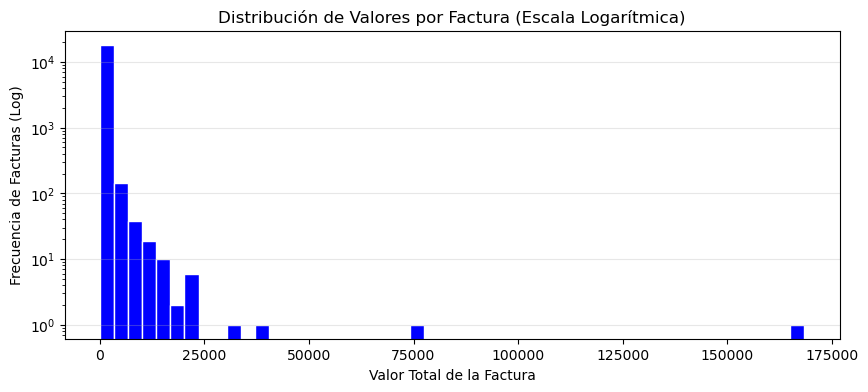

In [105]:
# Histograma de Totales de Facturas
facturas = totalesfacturas['totalprice']

plt.figure(figsize=(10, 4))
plt.hist(facturas, bins=50, color='blue', edgecolor='white')
plt.yscale('log')

plt.title('Distribución de Valores por Factura (Escala Logarítmica)')
plt.xlabel('Valor Total de la Factura')
plt.ylabel('Frecuencia de Facturas (Log)')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [106]:
# Cálculo de valores atípicos
# Cuartiles y RIQ (Rango Intercuartílico)
q1 = np.percentile(facturas, 25)
q3 = np.percentile(facturas, 75)
riq = q3 - q1

limite_sup = q3 + 1.5 * riq
outliers_riq = totalesfacturas[totalesfacturas['totalprice'] > limite_sup]

print(f"Límite RIQ: {limite_sup:.2f}. Facturas atípicas: {len(outliers_riq)}")

Límite RIQ: 937.91. Facturas atípicas: 1469


In [123]:
# Z-Score (Puntuación Z)
from scipy import stats

z_scores = stats.zscore(facturas)

# Se consideran outliers los que tienen un Z-score > 3
outliers_z = totalesfacturas[np.abs(z_scores) > 3]

In [124]:
print(outliers_z)

      invoiceno  totalprice
562      537657     9639.12
564      537659    15885.49
1127     539101     6930.00
1363     539731     8520.92
1491     540267     7011.38
...         ...         ...
18161    580727     8935.98
18310    581105     8345.20
18359    581175    10901.54
18481    581457    10363.82
18499    581483   168469.60

[99 rows x 2 columns]


In [114]:
# Winsorization
from scipy.stats.mstats import winsorize
# 'Transformamos' el 5% de los datos más altos
datos_winsorized = winsorize(facturas, limits=[0, 0.05])

In [119]:
print(datos_winsorized)

[139.12  22.2  278.73 ... 329.05 339.2  249.45]


In [116]:
from scipy.stats.mstats import winsorize
import pandas as pd

# Creamos una copia de totalesfacturas
totalesfacturas_clean = totalesfacturas.copy()

# Se aplica Winsorización al 5% superior (percentil 95)
# El parámetro limits=[0, 0.05] indica que no tocamos el mínimo y recortamos el 5% del máximo
totalesfacturas_clean['totalprice_winsor'] = winsorize(totalesfacturas['totalprice'], limits=[0, 0.05])

# Comparamos promedios
print(f"Media Original: {totalesfacturas['totalprice'].mean():.2f}")
print(f"Media Winsorizada: {totalesfacturas_clean['totalprice_winsor'].mean():.2f}")
print(f"Valor Máximo Original: {totalesfacturas['totalprice'].max():.2f}")
print(f"Valor Máximo Winsorizado: {totalesfacturas_clean['totalprice_winsor'].max():.2f}")

Media Original: 479.56
Media Winsorizada: 373.06
Valor Máximo Original: 168469.60
Valor Máximo Winsorizado: 1233.01
